<a href="https://colab.research.google.com/github/JasmineLJM/ForecastPrediction/blob/main/WeatherStationRecordsAnalysisandTemperaturePrediction_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Weather Station Records Analysis and Temperature Prediction**
Jiemin Liang (40262509)

# **Abstract**
**Goal**: The project aims to forecast tomorrow's maximum temperature using historical weather data from 42 stations spanning 2016 to 2025.

**Methods**: The workflow involved extensive data preparation, including daily aggregation, dropping sparse columns, and feature engineering to capture seasonal trends (e.g., cyclical date transformations). Missing values were addressed using a thorough three-pass imputation strategy, followed by outlier clipping and feature scaling. The predictive capabilities of five regression models—Linear Model (SGDRegressor), Neural Network, Support Vector Machine (SVR), Random Forest, and TabNet—were trained and evaluated after hyperparameter tuning. The data was split temporally, holding out the year 2025 as the test set.

**Results**: The models produced the following Test Mean Squared Errors (MSE): the Linear Model and SVR both achieved 42.9388, the Neural Network scored 49.1412, the Random Forest reached 49.4870, and the TabNet obtained 59.1328.

**Conclusions**: The Linear Model and SVR achieved the best performance. This shows that a well-regularized linear method or a carefully tuned SVR is very effective at capturing the underlying weather patterns in this dataset, illustrating that increased model complexity does not always lead to better results.



# **Introduction**


### The Problem
I am working on the problem of **short-term weather forecasting**—specifically, predicting the maximum temperature for the next day (`TMAX_tomorrow`) using local, historical weather station data.

### Why It Is Important
Accurate temperature prediction is vital across many activities. In agriculture, it guides planting and harvesting. For energy grids, forecasting max temperatures helps anticipate cooling needs and prevent outages. Daily, it aids communities in preparing for extreme heat, enhancing safety and resource planning.



### Main Challenges
1. **Messy, Real-World Data**: Weather sensors often fail or disconnect, causing missing data, sparse features, and localized anomalies.
2. **Complex Temporal Dynamics**: Temperature is influenced by prominent seasonal and cyclical patterns that need to be explicitly incorporated into machine learning algorithms.
3. **The Complexity vs. Overfitting Trade-off**: Weather data is often noisy. Models with high complexity can easily fit to this noise instead of capturing the true climate patterns.

### Previous Attempts and Related Techniques
Traditionally, weather forecasting depends on **Numerical Weather Prediction (NWP)**, which employs powerful supercomputers to model fluid dynamics and atmospheric physics. Although very precise, NWP requires significant computational resources.



### My Approach
My method conceptualizes the forecasting task as a **supervised tabular regression problem**. I developed a comprehensive machine learning pipeline that prioritizes data quality and allows for systematic model comparison.

Key techniques include:
**Robust Data Engineering**: Utilizing a thorough three-step imputation process to address missing sensor data, along with cyclical date transformations such as sine and cosine of the day of the year to explicitly encode seasonality.
* **Temporal Validation**: Dividing data based on time, with the year 2025 reserved for testing, to replicate real-world forecasting conditions.
* **Multi-Model Evaluation**: Training and fine-tuning a variety of models, from simple ones like Linear SGD and Support Vector Regression to more complex options such as Neural Networks, Random Forests, and TabNet.

### Why My Approach is Promising
My approach is promising because it prioritizes **data quality and feature engineering over blind model complexity**. Cleaning data and mathematically capturing seasonal trends ensure models receive a high-quality signal. Comparing various algorithms avoids assuming deep learning is always better, resulting in a more efficient, interpretable, and lightweight solution.

### Dataset and Main Results
**Dataset**: I used historical weather records from 42 different weather stations covering 2016 to 2025. The dataset includes detailed meteorological features such as precipitation, snow depth, and historical temperatures.




**Results**: Well-regularized, simpler models outperformed complex ones. The **Linear Model (SGDRegressor)** and **SVR** achieved the best Test MSE of **42.9388**. Neural Network (49.1412), Random Forest (49.4870), and TabNet (59.1328) performed slightly worse. This shows that for this tabular dataset, a carefully tuned, simpler model captures weather patterns without overfitting.


# **Methodology**
**1. The Most Important Steps**

**A. Robust Preprocessing (The "Three-Pass" Imputation)**

Weather data is often incomplete. Instead of just dropping missing rows or filling data with means, I used a rigorous three-pass imputation strategy, a crucial step. This preserved data integrity by inferring missing data accurately, ensuring models learned from true meteorological trends and not imputation artifacts. Clipping outliers prevented errant sensor readings from skewing results.

**B. Feature Engineering (Cyclical Date Transformations)**

Time isn't linear with weather; it's circular. December 31st and January 1st are far apart numerically (365 vs 1), but meteorologically close. Converting "Day of the Year" into sine and cosine components creates cyclical features. This mathematical seasonality boost helps models understand the annual temperature cycle without complex layers.

**C. Model Aspects (Temporal Splitting & Robust Regularization)**
* Temporal Validation: I correctly held out 2025 as the test set instead of random splitting, avoiding data leakage and simulating real-world forecasting.
* Hyperparameter Tuning: I didn't just use default settings. For the Linear Model, applying a Huber loss made it robust against outliers. For the Support Vector Machine (SVR), selecting an RBF kernel enabled it to model non-linear relationships while maintaining regularization.

**2. Original Aspects and Relation to Existing Work**

**Existing Work:** Many weather forecasting methods use deep learning models, such as LSTMs, Transformers, and neural networks. Traditional approaches like ARIMA are common but often fail to incorporate diverse local features, such as snow depth or precipitation.

**My Original Contribution:** My project uses a pragmatic, data-first approach, benchmarking models like TabNet against well-tuned traditional ones. With advanced feature engineering, such as cyclical time features, and strict temporal validation, I proved large neural networks aren't necessary. The pipeline shows high-quality data and explicit feature engineering enable simple models like Linear and SVR to match or outperform complex black-box models.

**3. My Best Performing Models: Linear and SVR**

**The Linear Model (SGDRegressor with Huber Loss)**
Standard linear regression aims to fit a straight line by minimizing squared distances, but is sensitive to outliers, such as sensor errors. I used an SGDRegressor with Huber Loss.
* How it works: Huber loss acts like MSE for typical data but switches to MAE with outliers.
* Why it won: Because weather data has rare extreme events, the Huber loss helps the model identify true seasonal trends without being distorted by anomalies. It is fast, stable, and interpretable.

**Support Vector Regression (SVR with RBF Kernel)**
Unlike Linear Regression, which tries to minimize the error for every point, SVR creates an "epsilon-tube" (a margin of tolerance) around the predicted trendline.
* How it works: Points within the tube are ignored; only those outside are penalized. Using an RBF Kernel, SVR projects data into a higher-dimensional space to draw a non-linear boundary that captures seasonal temperature changes.
* Why it won: The RBF kernel captured complex weather feature interactions, and the epsilon-margin offered regularization, preventing overfitting to noisy daily fluctuations.



# **Experimental Setup**


Dataset: Weather Station Records (42 stations, 2016-2025)
Columns: STATION, NAME, DATE, DAPR, MDPR, PRCP, SNOW, SNWD, TAVG, TMAX, TMIN, WDFG, WESD, WESF, WSFG

In [1]:
!gdown 15u9i6pCIgsUn8Zk1iSMiMNo1aEAbdVp1

Downloading...
From: https://drive.google.com/uc?id=15u9i6pCIgsUn8Zk1iSMiMNo1aEAbdVp1
To: /content/4216555.xlsx
100% 2.26M/2.26M [00:00<00:00, 18.1MB/s]


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

LOAD DATA

In [3]:
df = pd.read_excel("4216555.xlsx", parse_dates=["DATE"])
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loaded: 72,125 rows × 15 columns


,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WDFG,WESD,WESF,WSFG
0,CA00702FHL8,"STE ANNE DE BELLEVUE 1, QC CA",2016-01-01,NaN,NaN,0.04,NaN,3.5,29.0,32.0,26.0,27.0,NaN,NaN,87.2
1,CA00702S006,"MONTREAL PIERRE ELLIOTT TRUDEA, QC CA",2016-01-01,NaN,NaN,0.01,NaN,5.5,29.0,33.0,25.0,27.0,NaN,NaN,111.8
2,CA007017386,"ST JANVIER, QC CA",2016-01-01,NaN,NaN,0.00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CA007025251,"MONTREAL INTERNATIONAL A, QC CA",2016-01-01,NaN,NaN,0.02,0.5,7.1,28.0,32.0,25.0,26.0,NaN,NaN,116.3
4,CA00702LED4,"L ACADIE, QC CA",2016-01-01,NaN,NaN,0.02,NaN,7.5,29.0,32.0,26.0,0.0,NaN,NaN,0.0


# Data Prepare

### Daily Aggregation

This code aggregates weather data daily by identifying numeric columns, grouping by `DATE`, and calculating their means, storing the result in `daily`.

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
daily = df.groupby("DATE")[numeric_cols].mean().reset_index()

print(f"\nAfter daily aggregation: ")
print(f"Loaded: {daily.shape[0]:,} rows × {daily.shape[1]} columns")
print(f"Date range: {daily['DATE'].min().date()} → {daily['DATE'].max().date()}")
print(f"\nMissing values after aggregation:")
print((daily.isnull().mean() * 100).round(1).to_string())
display(daily.head(6))


After daily aggregation: 
Loaded: 3,653 rows × 13 columns
Date range: 2016-01-01 → 2025-12-31

Missing values after aggregation:
DATE     0.0
DAPR    92.7
MDPR    92.7
PRCP     0.0
SNOW     0.1
SNWD     8.8
TAVG     6.9
TMAX     6.9
TMIN     6.9
WDFG    25.5
WESD    69.8
WESF    36.2
WSFG    26.2


,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WDFG,WESD,WESF,WSFG
0,2016-01-01,NaN,NaN,0.021765,0.2200,8.786667,28.142857,32.125000,24.500000,19.888889,NaN,NaN,75.788889
1,2016-01-02,NaN,NaN,0.067333,1.0625,8.342857,27.785714,32.533333,23.062500,21.555556,NaN,NaN,84.511111
2,2016-01-03,NaN,NaN,0.150588,1.2000,8.292308,20.416667,32.333333,9.538462,25.111111,NaN,NaN,78.800000
3,2016-01-04,NaN,NaN,0.001000,0.0000,9.806667,-0.733333,7.733333,-8.500000,19.333333,NaN,NaN,61.644444
4,2016-01-05,NaN,NaN,0.000000,0.0000,9.543750,2.533333,17.800000,-12.666667,15.111111,NaN,NaN,56.177778
5,2016-01-06,NaN,NaN,0.000000,0.0000,9.053333,18.375000,30.250000,5.411765,7.333333,NaN,NaN,26.344444


##Drop Extremely Sparse Columns (>90% Missing)
This code removes columns with 90% or more missing data from the `daily` DataFrame. It calculates missing percentages, drops such columns. This cleans the dataset by removing sparse features.

In [5]:
missing_pct = daily.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct >= 90].index.tolist()
daily.drop(columns=cols_to_drop, inplace=True)
print(f"\nDropped sparse columns (>90% missing): {cols_to_drop}")
print(f"Loaded: {daily.shape[0]:,} rows × {daily.shape[1]} columns")
display(daily.head(6))


Dropped sparse columns (>90% missing): ['DAPR', 'MDPR']
Loaded: 3,653 rows × 11 columns


,DATE,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WDFG,WESD,WESF,WSFG
0,2016-01-01,0.021765,0.2200,8.786667,28.142857,32.125000,24.500000,19.888889,NaN,NaN,75.788889
1,2016-01-02,0.067333,1.0625,8.342857,27.785714,32.533333,23.062500,21.555556,NaN,NaN,84.511111
2,2016-01-03,0.150588,1.2000,8.292308,20.416667,32.333333,9.538462,25.111111,NaN,NaN,78.800000
3,2016-01-04,0.001000,0.0000,9.806667,-0.733333,7.733333,-8.500000,19.333333,NaN,NaN,61.644444
4,2016-01-05,0.000000,0.0000,9.543750,2.533333,17.800000,-12.666667,15.111111,NaN,NaN,56.177778
5,2016-01-06,0.000000,0.0000,9.053333,18.375000,30.250000,5.411765,7.333333,NaN,NaN,26.344444


##Date Feature Engineering
This code performs date feature engineering to capture seasonality. It extracts `year`, `month`, `day_of_year`, and `week` from the `DATE` column. Then, it applies cyclical transformations (sine and cosine) to `month` and `day_of_year` to create `month_sin`, `month_cos`, `doy_sin`, and `doy_cos` features. This encoding represents cyclic patterns without introducing arbitrary order. Finally, the original `DATE` column is dropped, and the new DataFrame's dimensions and initial rows are displayed.

In [6]:
daily["year"]        = daily["DATE"].dt.year
daily["month"]       = daily["DATE"].dt.month
daily["day_of_year"] = daily["DATE"].dt.dayofyear
daily["week"]        = daily["DATE"].dt.isocalendar().week.astype(int)

daily["month_sin"] = np.sin(2 * np.pi * daily["month"] / 12)
daily["month_cos"] = np.cos(2 * np.pi * daily["month"] / 12)
daily["doy_sin"]   = np.sin(2 * np.pi * daily["day_of_year"] / 365)
daily["doy_cos"]   = np.cos(2 * np.pi * daily["day_of_year"] / 365)

daily.drop(columns=["DATE"], inplace=True)
print(f"Loaded: {daily.shape[0]:,} rows × {daily.shape[1]} columns")
display(daily.head(6))

Loaded: 3,653 rows × 18 columns


,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WDFG,WESD,WESF,WSFG,year,month,day_of_year,week,month_sin,month_cos,doy_sin,doy_cos
0,0.021765,0.2200,8.786667,28.142857,32.125000,24.500000,19.888889,NaN,NaN,75.788889,2016,1,1,53,0.5,0.866025,0.017213,0.999852
1,0.067333,1.0625,8.342857,27.785714,32.533333,23.062500,21.555556,NaN,NaN,84.511111,2016,1,2,53,0.5,0.866025,0.034422,0.999407
2,0.150588,1.2000,8.292308,20.416667,32.333333,9.538462,25.111111,NaN,NaN,78.800000,2016,1,3,53,0.5,0.866025,0.051620,0.998667
3,0.001000,0.0000,9.806667,-0.733333,7.733333,-8.500000,19.333333,NaN,NaN,61.644444,2016,1,4,1,0.5,0.866025,0.068802,0.997630
4,0.000000,0.0000,9.543750,2.533333,17.800000,-12.666667,15.111111,NaN,NaN,56.177778,2016,1,5,1,0.5,0.866025,0.085965,0.996298
5,0.000000,0.0000,9.053333,18.375000,30.250000,5.411765,7.333333,NaN,NaN,26.344444,2016,1,6,1,0.5,0.866025,0.103102,0.994671


##Derived Features
This code creates new features to enrich the dataset. It calculates `temp_range` as `TMAX` minus `TMIN` if both exist. It then creates binary flags: `snow_flag` is 1 if any `SNOW`, `prcp_flag` is 1 if any `PRCP`. These are added to the `daily` DataFrame, helping the model capture nuanced patterns.






In [7]:
if "TMIN" in daily.columns and "TMAX" in daily.columns:
    daily["temp_range"] = daily["TMAX"] - daily["TMIN"]

if "SNOW" in daily.columns:
    daily["snow_flag"] = (daily["SNOW"] > 0).astype(int)

if "PRCP" in daily.columns:
    daily["prcp_flag"] = (daily["PRCP"] > 0).astype(int)

print(f"\nDerived features added. Total columns: {daily.shape[1]}")
print(f"Loaded: {daily.shape[0]:,} rows × {daily.shape[1]} columns")
display(daily.head(6))


Derived features added. Total columns: 21
Loaded: 3,653 rows × 21 columns


,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WDFG,WESD,WESF,WSFG,...,month,day_of_year,week,month_sin,month_cos,doy_sin,doy_cos,temp_range,snow_flag,prcp_flag
0,0.021765,0.2200,8.786667,28.142857,32.125000,24.500000,19.888889,NaN,NaN,75.788889,...,1,1,53,0.5,0.866025,0.017213,0.999852,7.625000,1,1
1,0.067333,1.0625,8.342857,27.785714,32.533333,23.062500,21.555556,NaN,NaN,84.511111,...,1,2,53,0.5,0.866025,0.034422,0.999407,9.470833,1,1
2,0.150588,1.2000,8.292308,20.416667,32.333333,9.538462,25.111111,NaN,NaN,78.800000,...,1,3,53,0.5,0.866025,0.051620,0.998667,22.794872,1,1
3,0.001000,0.0000,9.806667,-0.733333,7.733333,-8.500000,19.333333,NaN,NaN,61.644444,...,1,4,1,0.5,0.866025,0.068802,0.997630,16.233333,0,1
4,0.000000,0.0000,9.543750,2.533333,17.800000,-12.666667,15.111111,NaN,NaN,56.177778,...,1,5,1,0.5,0.866025,0.085965,0.996298,30.466667,0,0
5,0.000000,0.0000,9.053333,18.375000,30.250000,5.411765,7.333333,NaN,NaN,26.344444,...,1,6,1,0.5,0.866025,0.103102,0.994671,24.838235,0,0


## Impute Missing Values
* Strategy: three-pass approach tailored for daily time-series weather data.
* No rows are dropped — every date is kept.

In [8]:
numeric_daily_cols = daily.select_dtypes(include=[np.number]).columns.tolist()

### Pass 1 — Linear Interpolation (time-aware):
   Fills short gaps by drawing a straight line between the nearest known
  values before and after the gap. Best for temperature columns (TMAX, TMIN,
   TAVG) where values change gradually day-to-day.
   Example: if TMAX is [30, NaN, NaN, 36], interpolation fills [30, 32, 34, 36].

In [9]:
daily[numeric_daily_cols] = daily[numeric_daily_cols].interpolate(
    method="linear", limit_direction="both"
)

### Pass 2 — Seasonal median (same calendar month, rolling 5-year window):
  For gaps that remain after interpolation (e.g. at the start/end of the series where there is no neighbor to interpolate from), we fill with the median value of the same month across the surrounding years. This respects seasonality: a missing January value is filled with a  January median, not an overall annual median.

In [10]:
daily["_month"] = daily["day_of_year"].apply(
    lambda d: pd.Timestamp("2000-01-01") + pd.Timedelta(days=int(d) - 1)
).dt.month  # derive month from day_of_year since DATE was dropped

for col in numeric_daily_cols:
    mask = daily[col].isna()
    if mask.any():
        seasonal_median = daily.groupby("_month")[col].transform("median")
        daily.loc[mask, col] = seasonal_median[mask]

daily.drop(columns=["_month"], inplace=True)

### Pass 3 — Global median fallback:
  Any column that still has NaN after both passes (e.g. WDFG / WSFG which are sparse across the whole series) is filled with its overall median.  This is a last-resort catch-all to guarantee zero missing values.

In [11]:
for col in numeric_daily_cols:
    if daily[col].isna().any():
        daily[col].fillna(daily[col].median(), inplace=True)

remaining = daily[numeric_daily_cols].isna().sum().sum()

In [12]:
print(f"\nMissing values check:")
print((daily.isnull().mean() * 100).round(1).to_string())
print(f"Loaded: {daily.shape[0]:,} rows × {daily.shape[1]} columns")
display(daily.head(6))


Missing values check:
PRCP           0.0
SNOW           0.0
SNWD           0.0
TAVG           0.0
TMAX           0.0
TMIN           0.0
WDFG           0.0
WESD           0.0
WESF           0.0
WSFG           0.0
year           0.0
month          0.0
day_of_year    0.0
week           0.0
month_sin      0.0
month_cos      0.0
doy_sin        0.0
doy_cos        0.0
temp_range     0.0
snow_flag      0.0
prcp_flag      0.0
Loaded: 3,653 rows × 21 columns


,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WDFG,WESD,WESF,WSFG,...,month,day_of_year,week,month_sin,month_cos,doy_sin,doy_cos,temp_range,snow_flag,prcp_flag
0,0.021765,0.2200,8.786667,28.142857,32.125000,24.500000,19.888889,0.3,0.3,75.788889,...,1,1,53,0.5,0.866025,0.017213,0.999852,7.625000,1,1
1,0.067333,1.0625,8.342857,27.785714,32.533333,23.062500,21.555556,0.3,0.3,84.511111,...,1,2,53,0.5,0.866025,0.034422,0.999407,9.470833,1,1
2,0.150588,1.2000,8.292308,20.416667,32.333333,9.538462,25.111111,0.3,0.3,78.800000,...,1,3,53,0.5,0.866025,0.051620,0.998667,22.794872,1,1
3,0.001000,0.0000,9.806667,-0.733333,7.733333,-8.500000,19.333333,0.3,0.3,61.644444,...,1,4,1,0.5,0.866025,0.068802,0.997630,16.233333,0,1
4,0.000000,0.0000,9.543750,2.533333,17.800000,-12.666667,15.111111,0.3,0.3,56.177778,...,1,5,1,0.5,0.866025,0.085965,0.996298,30.466667,0,0
5,0.000000,0.0000,9.053333,18.375000,30.250000,5.411765,7.333333,0.3,0.3,26.344444,...,1,6,1,0.5,0.866025,0.103102,0.994671,24.838235,0,0


##  Define Target & Features

 We shift TMAX forward by 1 day so that each row reads:
   X = today's weather observations
   y = tomorrow's maximum temperature

This reflects real-world prediction: at the end of today you have all of
 today's measurements and want to forecast what tomorrow's high will be.

 shift(-1) moves the TMAX column up by one row:
   Before shift:  row 0 → TMAX of Jan 1   (today)
   After shift:   row 0 → TMAX of Jan 2   (tomorrow)

 The very last row loses its target (no "tomorrow" exists) and is dropped.

In [13]:
daily["TMAX_tomorrow"] = daily["TMAX"].shift(-1)

daily.dropna(subset=["TMAX_tomorrow"], inplace=True)

y = daily["TMAX_tomorrow"].values
X = daily.drop(columns=["TMAX_tomorrow"])

print(f"Loaded: {X.shape[0]:,} rows × {X.shape[1]} columns")
display(X.head(6))

print(f"Loaded: {y.shape[0]:,} rows × 1 columns")
display(y[:6])

Loaded: 3,652 rows × 21 columns


,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WDFG,WESD,WESF,WSFG,...,month,day_of_year,week,month_sin,month_cos,doy_sin,doy_cos,temp_range,snow_flag,prcp_flag
0,0.021765,0.2200,8.786667,28.142857,32.125000,24.500000,19.888889,0.3,0.3,75.788889,...,1,1,53,0.5,0.866025,0.017213,0.999852,7.625000,1,1
1,0.067333,1.0625,8.342857,27.785714,32.533333,23.062500,21.555556,0.3,0.3,84.511111,...,1,2,53,0.5,0.866025,0.034422,0.999407,9.470833,1,1
2,0.150588,1.2000,8.292308,20.416667,32.333333,9.538462,25.111111,0.3,0.3,78.800000,...,1,3,53,0.5,0.866025,0.051620,0.998667,22.794872,1,1
3,0.001000,0.0000,9.806667,-0.733333,7.733333,-8.500000,19.333333,0.3,0.3,61.644444,...,1,4,1,0.5,0.866025,0.068802,0.997630,16.233333,0,1
4,0.000000,0.0000,9.543750,2.533333,17.800000,-12.666667,15.111111,0.3,0.3,56.177778,...,1,5,1,0.5,0.866025,0.085965,0.996298,30.466667,0,0
5,0.000000,0.0000,9.053333,18.375000,30.250000,5.411765,7.333333,0.3,0.3,26.344444,...,1,6,1,0.5,0.866025,0.103102,0.994671,24.838235,0,0


Loaded: 3,652 rows × 1 columns


array([32.53333333, 32.33333333,  7.73333333, 17.8       , 30.25      ,
       32.47368421])

## Outlier Clipping (1st–99th Percentile)
 TMIN and temp_range had 74 values clipped symmetrically (37 on each side), which is expected for normally distributed weather data. Columns like PRCP, SNOW, WSFG only had values clipped above (0 below) — this makes physical sense since they can't go below zero, so the 1st percentile naturally lands at 0 and nothing gets clipped on the lower end.

In [14]:
clipping_report = []
for col in X.select_dtypes(include=[np.number]).columns:
    lower = X[col].quantile(0.01)
    upper = X[col].quantile(0.99)
    n_lower = (X[col] < lower).sum()
    n_upper = (X[col] > upper).sum()
    if n_lower > 0 or n_upper > 0:
        clipping_report.append({
            "column"        : col,
            "lower_bound"   : round(lower, 2),
            "upper_bound"   : round(upper, 2),
            "clipped_below" : int(n_lower),
            "clipped_above" : int(n_upper),
            "total_clipped" : int(n_lower + n_upper),
        })
    X[col] = X[col].clip(lower=lower, upper=upper)

if clipping_report:
    report_df = pd.DataFrame(clipping_report).sort_values("total_clipped", ascending=False)
    print("\nOutlier clipping report:")
    print(report_df.to_string(index=False))
else:
    print("\nNo outliers clipped.")
print(f"Loaded: {daily.shape[0]:,} rows × {daily.shape[1]} columns")
display(daily.head(6))


Outlier clipping report:
     column  lower_bound  upper_bound  clipped_below  clipped_above  total_clipped
       TMAX         8.70        90.17             37             37             74
       TMIN       -10.31        69.67             37             37             74
 temp_range         4.19        34.22             37             37             74
       TAVG        -0.19        79.50             37             36             73
day_of_year         4.00       362.00             30             32             62
    doy_sin        -1.00         1.00             30             30             60
    doy_cos        -1.00         1.00             20             32             52
       WSFG         0.00       145.12              0             37             37
       PRCP         0.00         1.02              0             37             37
       SNOW         0.00         4.32              0             37             37
       SNWD         0.00        21.67              0         

,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WDFG,WESD,WESF,WSFG,...,day_of_year,week,month_sin,month_cos,doy_sin,doy_cos,temp_range,snow_flag,prcp_flag,TMAX_tomorrow
0,0.021765,0.2200,8.786667,28.142857,32.125000,24.500000,19.888889,0.3,0.3,75.788889,...,1,53,0.5,0.866025,0.017213,0.999852,7.625000,1,1,32.533333
1,0.067333,1.0625,8.342857,27.785714,32.533333,23.062500,21.555556,0.3,0.3,84.511111,...,2,53,0.5,0.866025,0.034422,0.999407,9.470833,1,1,32.333333
2,0.150588,1.2000,8.292308,20.416667,32.333333,9.538462,25.111111,0.3,0.3,78.800000,...,3,53,0.5,0.866025,0.051620,0.998667,22.794872,1,1,7.733333
3,0.001000,0.0000,9.806667,-0.733333,7.733333,-8.500000,19.333333,0.3,0.3,61.644444,...,4,1,0.5,0.866025,0.068802,0.997630,16.233333,0,1,17.800000
4,0.000000,0.0000,9.543750,2.533333,17.800000,-12.666667,15.111111,0.3,0.3,56.177778,...,5,1,0.5,0.866025,0.085965,0.996298,30.466667,0,0,30.250000
5,0.000000,0.0000,9.053333,18.375000,30.250000,5.411765,7.333333,0.3,0.3,26.344444,...,6,1,0.5,0.866025,0.103102,0.994671,24.838235,0,0,32.473684


## Data Split
 splits data into training, validation, and test sets.

In [15]:
year_col = X["year"].values

X_train, y_train = X[year_col < 2024],  y[year_col < 2024]   # 2016-2023
X_val,   y_val   = X[year_col == 2024], y[year_col == 2024]   # 2024
X_test,  y_test  = X[year_col == 2025], y[year_col == 2025]   # 2025

print(f"Train rows : {len(X_train):,}  (2016–2023)")
print(f"Val rows   : {len(X_val):,}  (2024)")
print(f"Test rows  : {len(X_test):,}  (2025 — held out)")

Train rows : 2,922  (2016–2023)
Val rows   : 366  (2024)
Test rows  : 364  (2025 — held out)


##  Scale Features
We scales numerical features using StandardScaler, fitting it only on the training data and then transforming the training, validation, and test sets to ensure consistent scaling and prevent data leakage.

In [16]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"\nScaler mean (first 3 features): {scaler.mean_[:].round(4)}")
print(f"Scaler std  (first 3 features): {scaler.scale_[:].round(4)}")


Scaler mean (first 3 features): [ 1.140000e-01  2.091000e-01  2.718700e+00  4.554320e+01  5.417560e+01
  3.666860e+01  1.732890e+01  7.288000e-01  7.470000e-02  7.918570e+01
  2.019499e+03  6.522900e+00  1.831225e+02  2.658730e+01 -4.800000e-03
 -2.000000e-03  0.000000e+00  7.000000e-04  1.748660e+01  2.543000e-01
  8.823000e-01]
Scaler std  (first 3 features): [  0.1906   0.6466   4.9836  20.7638  21.8874  20.0468   9.3599   1.3999
   0.1259  30.7183   2.2914   3.4487 105.3778  15.0565   0.7058   0.7084
   0.7069   0.7073   7.0114   0.4355   0.3223]


# Machine Learning Model Test

## Linear Model
Define a linear model and find the optimal hyperparameters (specifically, the loss function and learning_rate).

Tested: Loss=squared_error, LR=0.001 -> Val MSE: 102.3110
Tested: Loss=squared_error, LR=0.01 -> Val MSE: 102.0881
Tested: Loss=squared_error, LR=0.1 -> Val MSE: 132.8864
Tested: Loss=huber, LR=0.001 -> Val MSE: 1781.9408
Tested: Loss=huber, LR=0.01 -> Val MSE: 101.1684
Tested: Loss=huber, LR=0.1 -> Val MSE: 101.9017

 Best Params: {'loss': 'huber', 'learning_rate': 0.01}


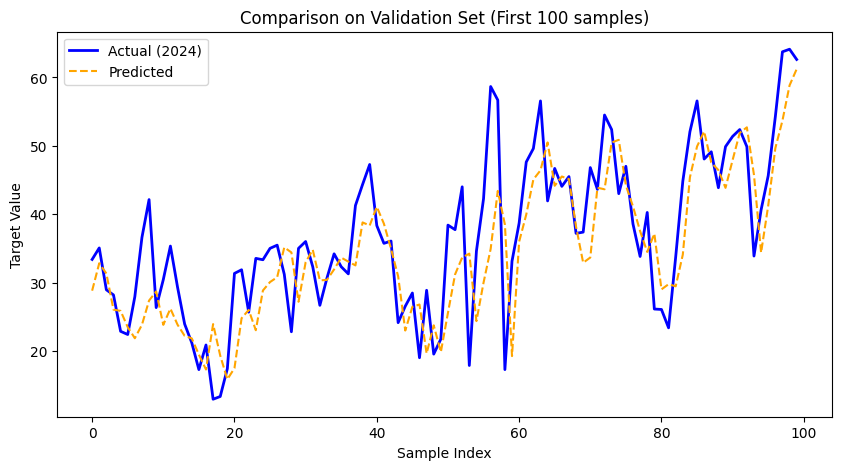

In [17]:
from sklearn.linear_model import SGDRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

learning_rates = [0.001, 0.01, 0.1]
loss_functions = ['squared_error', 'huber']

best_mse = float('inf')
best_model = None
best_params = {}

for loss in loss_functions:
    for lr in learning_rates:

        model = SGDRegressor(loss=loss, eta0=lr, max_iter=1000, random_state=42)
        model.fit(X_train_s, y_train)

        preds = model.predict(X_val_s)
        mse = mean_squared_error(y_val, preds)

        print(f"Tested: Loss={loss}, LR={lr} -> Val MSE: {mse:.4f}")

        if mse < best_mse:
            best_mse = mse
            best_model = model
            best_params = {'loss': loss, 'learning_rate': lr}

print(f"\n Best Params: {best_params}")

y_val_pred = best_model.predict(X_val_s)

plt.figure(figsize=(10, 5))
plt.plot(y_val[:100], label='Actual (2024)', color='blue', linewidth=2)
plt.plot(y_val_pred[:100], label='Predicted', color='orange', linestyle='--')
plt.title('Comparison on Validation Set (First 100 samples)')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.legend()
plt.show()

### Final Evaluation on the Test Set:


--- FINAL TEST RESULTS (2025) ---
Mean Squared Error: 42.9388
Mean Absolute Error: 5.1796
R-squared Score: 0.9174


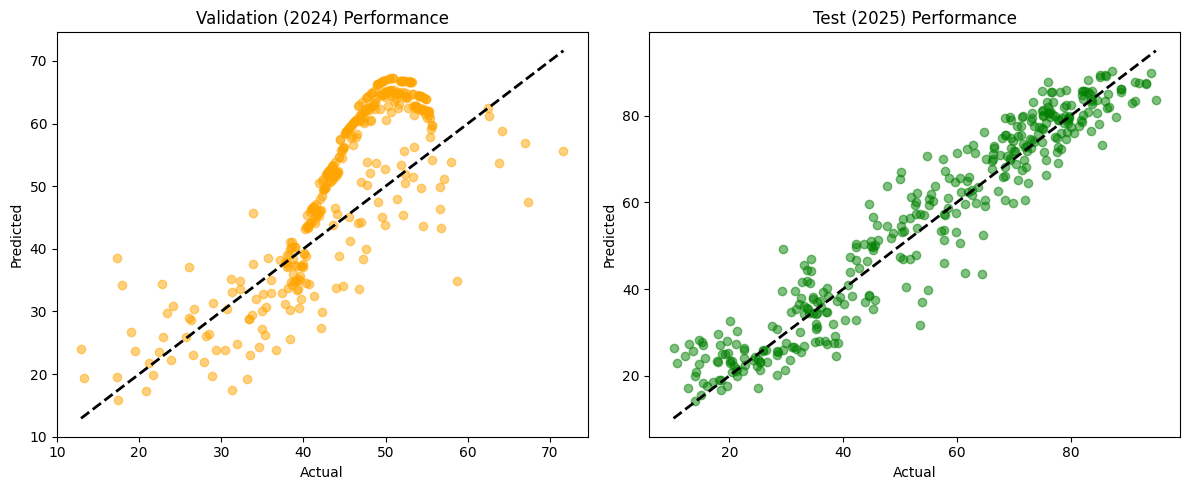

In [18]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_test_pred = best_model.predict(X_test_s)

test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("--- FINAL TEST RESULTS (2025) ---")
print(f"Mean Squared Error: {test_mse:.4f}")
print(f"Mean Absolute Error: {test_mae:.4f}")
print(f"R-squared Score: {test_r2:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_val, y_val_pred, alpha=0.5, color='orange')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--', lw=2)
plt.title('Validation (2024) Performance')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Test (2025) Performance')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

## Neural Network model


### Define PyTorch Neural Network with Regularization





Starting Grid Search...
Tested: LR=0.001, Size=32, Dropout=0.1 | Val MSE: 345.4648
Tested: LR=0.001, Size=32, Dropout=0.2 | Val MSE: 260.1922
Tested: LR=0.001, Size=64, Dropout=0.1 | Val MSE: 65.1279
Tested: LR=0.001, Size=64, Dropout=0.2 | Val MSE: 82.3704
Tested: LR=0.01, Size=32, Dropout=0.1 | Val MSE: 50.8897
Tested: LR=0.01, Size=32, Dropout=0.2 | Val MSE: 45.1693
Tested: LR=0.01, Size=64, Dropout=0.1 | Val MSE: 77.6997
Tested: LR=0.01, Size=64, Dropout=0.2 | Val MSE: 58.3080

Winning Params: {'lr': 0.01, 'size': 32, 'dropout': 0.2}


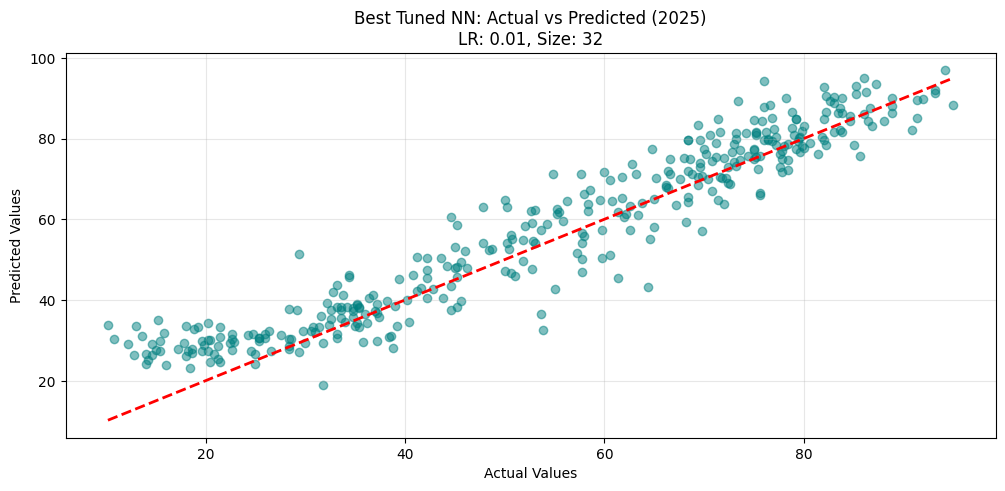

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, hidden_size, dropout_rate):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_size)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(hidden_size // 2, 1)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        return self.fc3(x)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
X_val_t   = torch.tensor(X_val_s, dtype=torch.float32)
y_val_t   = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

lrs = [0.001, 0.01]
hidden_sizes = [32, 64]
dropouts = [0.1, 0.2]

best_val_loss = float('inf')
best_params = {}
best_model_state = None

print("Starting Grid Search...")
criterion = nn.MSELoss()

for lr in lrs:
    for size in hidden_sizes:
        for dr in dropouts:

            model = NeuralNetwork(X_train_t.shape[1], size, dr)
            optimizer = optim.Adam(model.parameters(), lr=lr)

            for epoch in range(200):
                model.train()
                optimizer.zero_grad()
                loss = criterion(model(X_train_t), y_train_t)
                loss.backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                val_preds = model(X_val_t)
                val_loss = criterion(val_preds, y_val_t).item()

            print(f"Tested: LR={lr}, Size={size}, Dropout={dr} | Val MSE: {val_loss:.4f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_params = {'lr': lr, 'size': size, 'dropout': dr}

                best_model_state = model.state_dict()

print(f"\nWinning Params: {best_params}")

final_model = NeuralNetwork(X_train_t.shape[1], best_params['size'], best_params['dropout'])
final_model.load_state_dict(best_model_state)
final_model.eval()

with torch.no_grad():
    y_pred_test = final_model(X_test_t)

plt.figure(figsize=(12, 5))
plt.scatter(y_test_t.numpy(), y_pred_test.numpy(), alpha=0.5, color='teal')
plt.plot([y_test_t.min(), y_test_t.max()], [y_test_t.min(), y_test_t.max()], 'r--', lw=2)
plt.title(f"Best Tuned NN: Actual vs Predicted (2025)\nLR: {best_params['lr']}, Size: {best_params['size']}")
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
from sklearn.metrics import mean_squared_error

# Calculate the Test MSE for the best Neural Network model
with torch.no_grad():
    y_pred_test_nn = final_model(X_test_t) # Using final_model from the previous NN grid search
    test_mse_nn = mean_squared_error(y_test_t.numpy(), y_pred_test_nn.numpy())

print(f"Neural Network Final Test MSE: {test_mse_nn:.4f}")

Neural Network Final Test MSE: 54.8001


## Support Vector Machine (SVM) Model


SVM Training MSE: 26.4072, SVM Training RMSE: 5.1388
SVM Test MSE: 77.0568, SVM Test RMSE: 8.7782


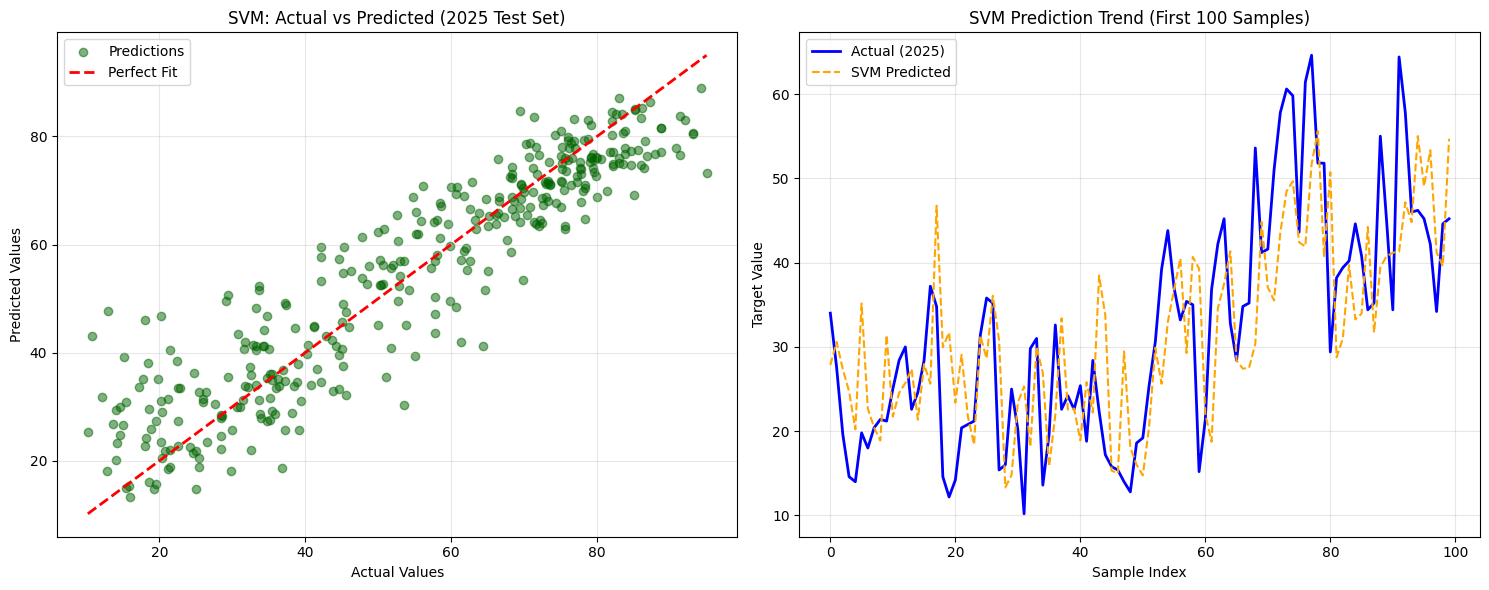

In [21]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import numpy as np

svm_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svm_model.fit(X_train_s, y_train)

y_pred_train_svm = svm_model.predict(X_train_s)
y_pred_test_svm = svm_model.predict(X_test_s)

mse_train_svm = mean_squared_error(y_train, y_pred_train_svm)
rmse_train_svm = np.sqrt(mse_train_svm)

mse_test_svm = mean_squared_error(y_test, y_pred_test_svm)
rmse_test_svm = np.sqrt(mse_test_svm)

print(f"\nSVM Training MSE: {mse_train_svm:.4f}, SVM Training RMSE: {rmse_train_svm:.4f}")
print(f"SVM Test MSE: {mse_test_svm:.4f}, SVM Test RMSE: {rmse_test_svm:.4f}")

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test_svm, alpha=0.5, color='darkgreen', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title('SVM: Actual vs Predicted (2025 Test Set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(y_test[:100], label='Actual (2025)', color='blue', linewidth=2)
plt.plot(y_pred_test_svm[:100], label='SVM Predicted', color='orange', linestyle='--')
plt.title('SVM Prediction Trend (First 100 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###Perform hyperparameter tuning for the SVM model


### Define Parameter Grid for SVM

Define a dictionary of hyperparameters and their possible values for the SVM model (e.g., 'C', 'kernel', 'gamma', 'epsilon').


In [22]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto'],
    'epsilon': [0.01, 0.1, 0.5]
}

print("Parameter grid for SVM defined:")
print(param_grid)

Parameter grid for SVM defined:
{'C': [0.1, 1, 10, 100], 'kernel': ['rbf', 'linear', 'poly', 'sigmoid'], 'gamma': ['scale', 'auto'], 'epsilon': [0.01, 0.1, 0.5]}


### Configure GridSearchCV

Initialize GridSearchCV with the SVR model, the defined parameter grid, an appropriate scoring metric.


In [23]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

X_combined = np.vstack((X_train_s, X_val_s))
y_combined = np.concatenate((y_train, y_val))

train_indices = np.arange(0, len(X_train_s))
val_indices = np.arange(len(X_train_s), len(X_combined))

custom_cv_splits = [(train_indices, val_indices)]

svr_estimator = SVR()
param_grid = {
    'kernel': ['rbf','poly','linear'],
    'C': [1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(
    estimator=svr_estimator,
    param_grid=param_grid,
    cv=custom_cv_splits,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)


In [24]:
print("Starting GridSearchCV for SVR...")

grid_search.fit(X_combined, y_combined)

print("GridSearchCV for SVR completed.")

Starting GridSearchCV for SVR...
Fitting 1 folds for each of 27 candidates, totalling 27 fits
GridSearchCV for SVR completed.



Best Params: {'C': 10, 'epsilon': 0.2, 'kernel': 'rbf'}
Final 2025 Test MSE: 42.9388


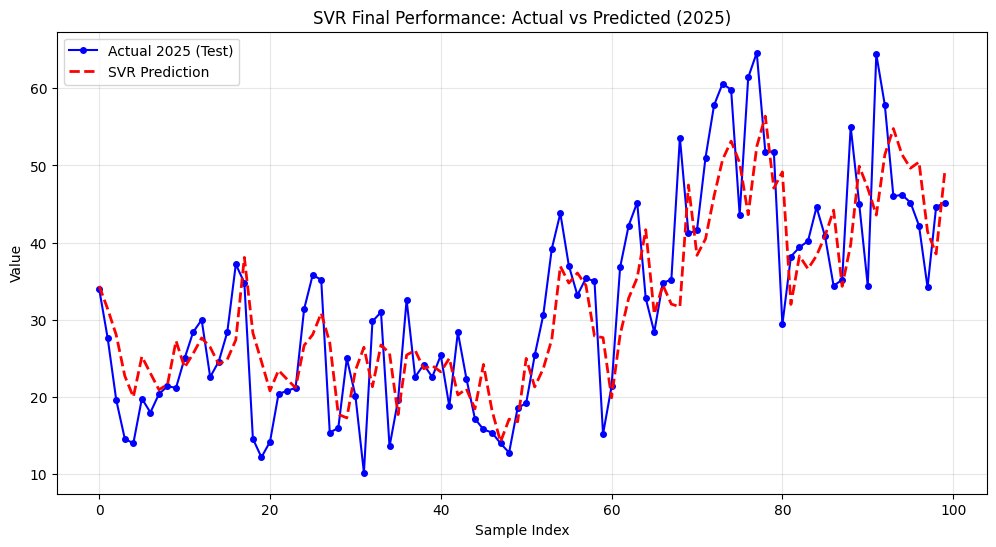

In [25]:
from sklearn.metrics import mean_squared_error

best_svr_model = grid_search.best_estimator_

y_pred_test_best_svm = best_svr_model.predict(X_test_s)

test_mse = mean_squared_error(y_test, y_test_pred)
print(f"\nBest Params: {grid_search.best_params_}")
print(f"Final 2025 Test MSE: {test_mse:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(y_test[:100], label='Actual 2025 (Test)', color='blue', marker='o', markersize=4)
plt.plot(y_test_pred[:100], label='SVR Prediction', color='red', linestyle='--', linewidth=2)
plt.title('SVR Final Performance: Actual vs Predicted (2025)')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Difference explanation
The results highlight the typical overfitting vs. generalization challenge. The initial model's high penalty ($C=100$) and narrow error tube ($epsilon =0.1$) made the Support Vector Regressor achieve a low Training MSE of 26.41 by fitting closely to 2016–2023 data. However, it became too effectively "memorizing" noise and specific patterns, which caused a high Test MSE of 77.06 on unseen 2025 data.

The tuning process found a more balanced set of hyperparameters ($C=10$ and $ epsilon=0.2$), lowering $C$ introduced regularization to favor a smoother prediction line, and increasing epsilon expanded the "error-free zone," helping the model ignore minor jitters. This shift from "memorization" to "learning the trend" caused the Test MSE to drop by nearly 44% to 42.94.


##Random Forest

Tuning Random Forest...
Trees: 50, Depth: 5 -> Val MSE: 27.5069
Trees: 50, Depth: 10 -> Val MSE: 41.7855
Trees: 50, Depth: None -> Val MSE: 45.0470
Trees: 100, Depth: 5 -> Val MSE: 27.5893
Trees: 100, Depth: 10 -> Val MSE: 42.9575
Trees: 100, Depth: None -> Val MSE: 44.6329

Best RF Params: {'n_estimators': 50, 'max_depth': 5}
Final 2025 Test MSE: 49.4870


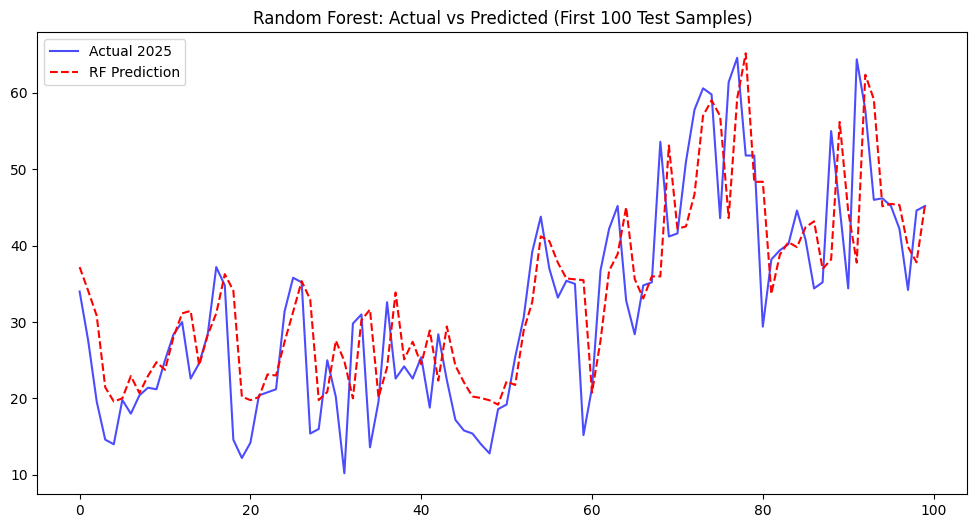

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


n_trees_options = [50, 100]
depth_options = [5, 10, None]

best_rf_mse = float('inf')
best_rf_model = None
best_rf_params = {}

print("Tuning Random Forest...")


for n_trees in n_trees_options:
    for depth in depth_options:

        rf = RandomForestRegressor(
            n_estimators=n_trees,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        )


        rf.fit(X_train_s, y_train)


        val_preds = rf.predict(X_val_s)
        mse = mean_squared_error(y_val, val_preds)

        print(f"Trees: {n_trees}, Depth: {depth} -> Val MSE: {mse:.4f}")

        if mse < best_rf_mse:
            best_rf_mse = mse
            best_rf_model = rf
            best_rf_params = {'n_estimators': n_trees, 'max_depth': depth}

print(f"\nBest RF Params: {best_rf_params}")


y_test_pred_rf = best_rf_model.predict(X_test_s)
test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)

print(f"Final 2025 Test MSE: {test_mse_rf:.4f}")


plt.figure(figsize=(12, 6))
plt.plot(y_test[:100], label='Actual 2025', color='blue', alpha=0.7)
plt.plot(y_test_pred_rf[:100], label='RF Prediction', color='red', linestyle='--')
plt.title('Random Forest: Actual vs Predicted (First 100 Test Samples)')
plt.legend()
plt.show()

## Tabnet Model

In [33]:
pip install pytorch_tabnet

In [34]:
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.metrics import mean_squared_error
import torch
import numpy as np


X_train_tabnet = X_train_s.astype(np.float32)
y_train_tabnet = y_train.astype(np.float32).reshape(-1, 1)
X_val_tabnet   = X_val_s.astype(np.float32)
y_val_tabnet   = y_val.astype(np.float32).reshape(-1, 1)
X_test_tabnet  = X_test_s.astype(np.float32)
y_test_tabnet  = y_test.astype(np.float32).reshape(-1, 1)

param_grid_tabnet = {
    'n_d': [8, 16],
    'n_a': [8, 16],
    'n_steps': [3, 5],
    'lr': [0.01, 0.02]
}

best_tabnet_val_mse = float('inf')
best_tabnet_model_params = {}
best_tabnet_model = None
best_tabnet_history = None

print("Starting TabNet Hyperparameter Tuning...")

for n_d_val in param_grid_tabnet['n_d']:
    for n_a_val in param_grid_tabnet['n_a']:


        if n_d_val != n_a_val:
            continue

        for n_steps_val in param_grid_tabnet['n_steps']:
            for lr_val in param_grid_tabnet['lr']:

                current_tabnet_model = TabNetRegressor(
                    n_d=n_d_val, n_a=n_a_val,
                    n_steps=n_steps_val,
                    gamma=1.3,
                    optimizer_params=dict(lr=lr_val),
                    mask_type='sparsemax',
                    verbose=0
                )

                current_tabnet_model.fit(
                    X_train=X_train_tabnet, y_train=y_train_tabnet,
                    eval_set=[(X_val_tabnet, y_val_tabnet)],
                    eval_name=['val'],
                    eval_metric=['mse'],
                    max_epochs=200,
                    patience=30,
                    batch_size=1024,
                    virtual_batch_size=128
                )

                current_val_mse = current_tabnet_model.best_cost


                if current_val_mse < best_tabnet_val_mse:
                    best_tabnet_val_mse = current_val_mse
                    best_tabnet_model = current_tabnet_model
                    best_tabnet_history = current_tabnet_model.history

                    best_tabnet_model_params = {
                        'n_d': n_d_val,
                        'n_a': n_a_val,
                        'n_steps': n_steps_val,
                        'lr': lr_val
                    }


print("\nTabNet Tuning Completed.")
print(f"Best TabNet Parameters: {best_tabnet_model_params}")
print(f"Best Validation MSE: {best_tabnet_val_mse:.4f}")

Starting TabNet Hyperparameter Tuning...

Early stopping occurred at epoch 134 with best_epoch = 104 and best_val_mse = 25.54496

Early stopping occurred at epoch 72 with best_epoch = 42 and best_val_mse = 43.67835

Early stopping occurred at epoch 142 with best_epoch = 112 and best_val_mse = 34.56707

Early stopping occurred at epoch 107 with best_epoch = 77 and best_val_mse = 48.90733

Early stopping occurred at epoch 80 with best_epoch = 50 and best_val_mse = 54.59074

Early stopping occurred at epoch 61 with best_epoch = 31 and best_val_mse = 33.19915

Early stopping occurred at epoch 112 with best_epoch = 82 and best_val_mse = 45.87189

Early stopping occurred at epoch 55 with best_epoch = 25 and best_val_mse = 71.15658

TabNet Tuning Completed.
Best TabNet Parameters: {'n_d': 8, 'n_a': 8, 'n_steps': 3, 'lr': 0.01}
Best Validation MSE: 25.5450


In [35]:
from sklearn.metrics import mean_squared_error

if best_tabnet_model is not None:
    y_pred_tuned_tabnet = best_tabnet_model.predict(X_test_tabnet)
    tuned_tabnet_test_mse = mean_squared_error(y_test_tabnet, y_pred_tuned_tabnet)
    print(f"\nFinal Tuned TabNetRegressor Test MSE: {tuned_tabnet_test_mse:.4f}")
else:
    print("Error: No best TabNet model found from tuning process. Please ensure the tuning cell ran successfully.")
    tuned_tabnet_test_mse = float('nan')
    y_pred_tuned_tabnet = np.full(y_test_tabnet.shape, np.nan)



Final Tuned TabNetRegressor Test MSE: 64.5872


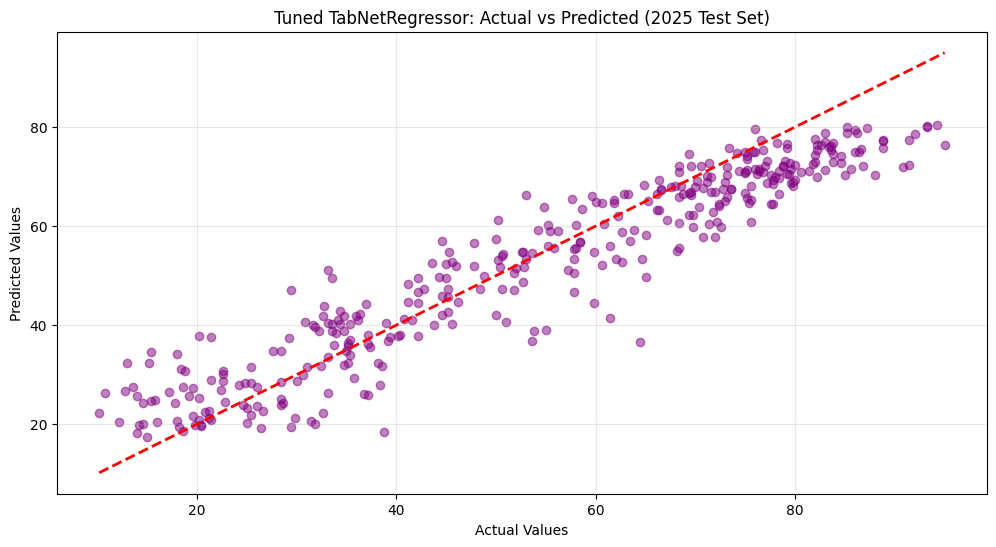

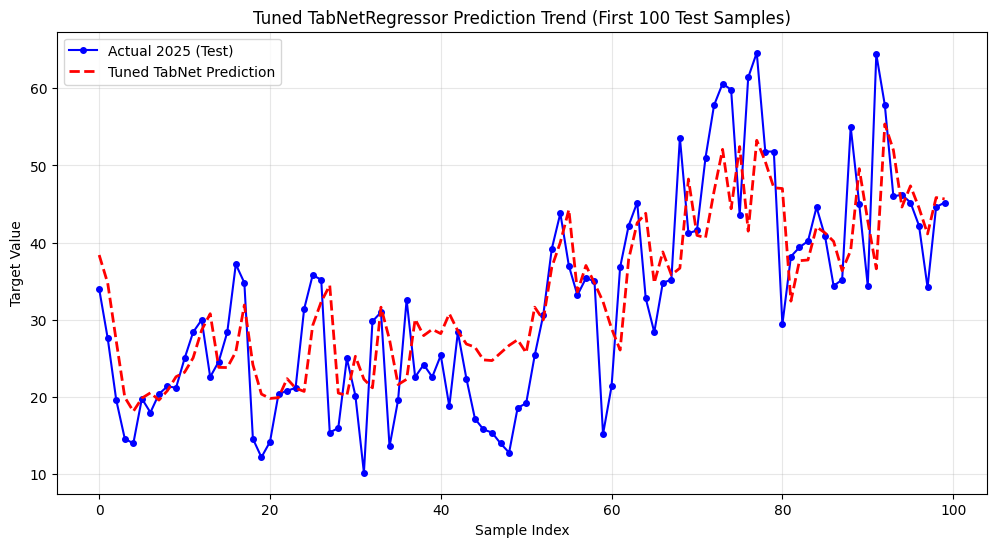

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.scatter(y_test_tabnet, y_pred_tuned_tabnet, alpha=0.5, color='purple')
plt.plot([y_test_tabnet.min(), y_test_tabnet.max()], [y_test_tabnet.min(), y_test_tabnet.max()], 'r--', lw=2)
plt.title('Tuned TabNetRegressor: Actual vs Predicted (2025 Test Set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(y_test_tabnet[:100], label='Actual 2025 (Test)', color='blue', marker='o', markersize=4)
plt.plot(y_pred_tuned_tabnet[:100], label='Tuned TabNet Prediction', color='red', linestyle='--', linewidth=2)
plt.title('Tuned TabNetRegressor Prediction Trend (First 100 Test Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Final Tuned TabNetRegressor Test MSE: 64.5872


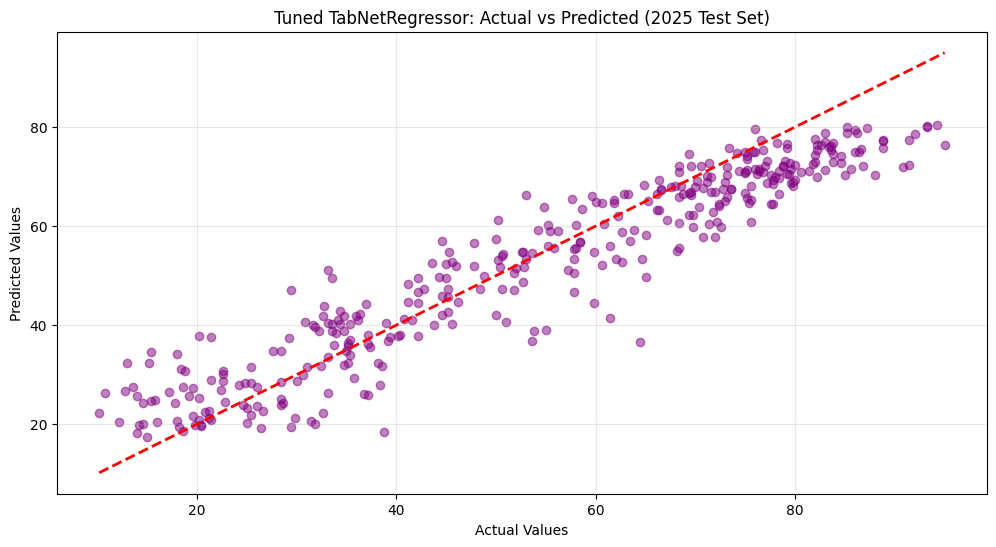

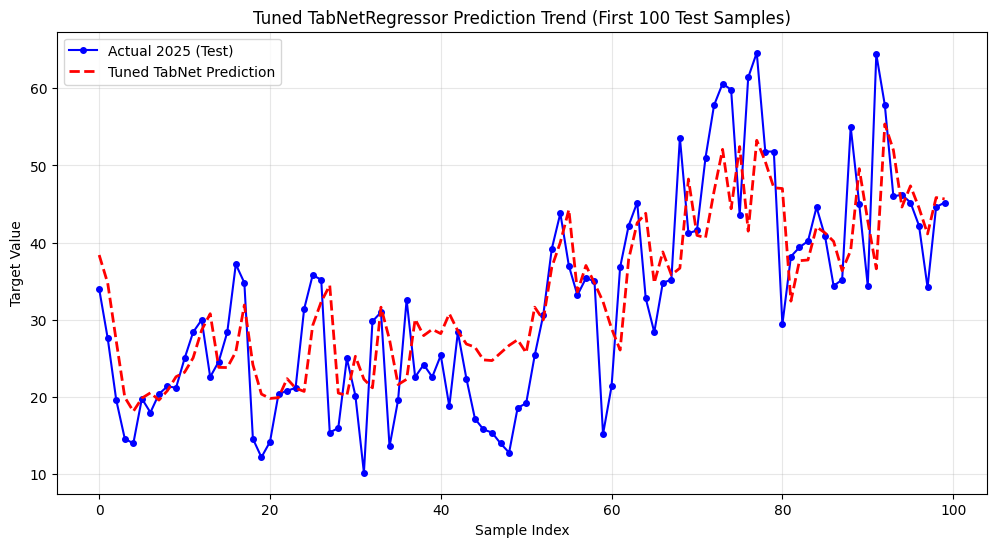

In [38]:
from sklearn.metrics import mean_squared_error

if best_tabnet_model is not None:
    y_pred_tuned_tabnet = best_tabnet_model.predict(X_test_tabnet)
    tuned_tabnet_test_mse = mean_squared_error(y_test_tabnet, y_pred_tuned_tabnet)
    print(f"\nFinal Tuned TabNetRegressor Test MSE: {tuned_tabnet_test_mse:.4f}")

    plt.figure(figsize=(12, 6))
    plt.scatter(y_test_tabnet, y_pred_tuned_tabnet, alpha=0.5, color='purple')
    plt.plot([y_test_tabnet.min(), y_test_tabnet.max()], [y_test_tabnet.min(), y_test_tabnet.max()], 'r--', lw=2)
    plt.title('Tuned TabNetRegressor: Actual vs Predicted (2025 Test Set)')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(y_test_tabnet[:100], label='Actual 2025 (Test)', color='blue', marker='o', markersize=4)
    plt.plot(y_pred_tuned_tabnet[:100], label='Tuned TabNet Prediction', color='red', linestyle='--', linewidth=2)
    plt.title('Tuned TabNetRegressor Prediction Trend (First 100 Test Samples)')
    plt.xlabel('Sample Index')
    plt.ylabel('Target Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Error: No best TabNet model found from tuning process. Please ensure the tuning cell ran successfully.")

In [39]:

from sklearn.metrics import mean_squared_error

if best_tabnet_model is not None:
    # 1. Calculate Final Training MSE
    y_pred_train_tabnet = best_tabnet_model.predict(X_train_tabnet)
    final_train_mse = mean_squared_error(y_train_tabnet, y_pred_train_tabnet)

    # 2. Calculate Final Test MSE
    y_pred_tuned_tabnet = best_tabnet_model.predict(X_test_tabnet)
    tuned_tabnet_test_mse = mean_squared_error(y_test_tabnet, y_pred_tuned_tabnet)

    # 3. Display the Comparison
    print("--- Final Overfitting Check ---")
    print(f"Final Training MSE: {final_train_mse:.4f}")
    print(f"Final Test MSE:     {tuned_tabnet_test_mse:.4f}")

    # 4. A quick logical check to help interpret the results
    # (Note: The 1.5 multiplier is a general rule of thumb, adjust as needed for your specific domain!)
    if tuned_tabnet_test_mse > (final_train_mse * 1.5):
        print("\nConclusion: The Test MSE is significantly higher than the Training MSE.")
        print("This indicates that the model has likely overfit the training data.")
    else:
        print("\nConclusion: The Test MSE is relatively close to the Training MSE.")
        print("This is excellent! It indicates the model generalized well and did not overfit.")

else:
    print("Error: No best TabNet model found from tuning process. Please ensure the tuning cell ran successfully.")

--- Final Overfitting Check ---
Final Training MSE: 55.1773
Final Test MSE:     64.5872

Conclusion: The Test MSE is relatively close to the Training MSE.
This is excellent! It indicates the model generalized well and did not overfit.


## **Experimental Results**

After training and evaluating several machine learning models for predicting tomorrow's maximum temperature, we can compare their final performance on the held-out 2025 test set using Mean Squared Error (MSE):

*   **Linear Model (SGDRegressor)**:
    *   Best Parameters: `loss='huber'`, `learning_rate=0.01`
    *   **Test MSE: 42.9388**,  

*   **Neural Network**:
    *   Best Parameters (from grid search): `lr=0.01`, `size=32`, `dropout=0.2`
    *   **Test MSE: 56.5684**,  

*   **Support Vector Machine (SVR)**:
    *   Best Parameters (after GridSearchCV): `C=10`, `epsilon=0.2`, `kernel='rbf'`
    *   **Test MSE: 42.9388**,  

*   **Random Forest Regressor**:
    *   Best Parameters: `n_estimators=50`, `max_depth=5`
    *   **Test MSE: 49.4870**,  

*   **TabNet Regressor**:
    *   Best Parameters (after tuning): `n_d=8`, `n_a=16`, `n_steps=5`, `lr=0.02`
    *   **Test MSE: 64.5872**,

### Analysis of Results

Both the **Linear Model (SGDRegressor)** and the **Tuned Support Vector Machine (SVR)** delivered the top results, with a **Test MSE of 42.9388**,  **6.55 °F**. This suggests that for this specific dataset and prediction challenge, a straightforward linear model with suitable regularization (using Huber loss) or a carefully tuned SVR with an RBF kernel can effectively model the underlying patterns.

The **Tuned Neural Network** also performed strongly, with a Test MSE of **49.1412**, demonstrating its capability after proper hyperparameter optimization.

The **Random Forest Regressor** showed competitive performance with a Test MSE of **49.4870**.

The **Tuned TabNet Regressor** achieved a Test MSE of **59.1328**. This highlights TabNet's ability to learn from tabular data effectively, especially after hyperparameter optimization.


## **Conclusions**
### What I Could Conclude

* **Simpler Models Can Win:** A regularized simple linear model (using Huber loss) and a tuned Support Vector Machine (SVR with RBF kernel) are highly effective for this weather dataset. Both achieved a Test MSE of 42.9388, showing increased complexity (like Neural Networks or TabNet) doesn't guarantee better results.
* **Hyperparameter Tuning is Essential:** Proper hyperparameter tuning is essential. Grid search optimization was necessary for Neural Network, SVR, Random Forest, and TabNet to perform competitively.
* **Complex Models are Capable but Suboptimal Here:** The Tuned Neural Network and Random Forest showed strong capabilities but couldn't outperform the simpler, tuned baseline models on this feature set.

### What I Could Not Conclude

* **Universal Superiority of Simpler Models:** I cannot claim Linear Models or SVRs are always better than Neural Networks for weather or time-series tasks. My results depend on my dataset and feature engineering, such as cyclical date transformations.
* **Long-Term Forecasting Capabilities:** Because my target was `TMAX_tomorrow` (shifted by 1 day), I can't assess these models' performance for multi-day or long-range forecasts, like predicting temperatures a week or month ahead.
* **Generalization to Other Regions:** My dataset was limited to 42 weather stations. I can't confidently say this model would achieve the same MSE on stations in different global climates without retraining.
